In [1]:
#import required libraries
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

Task1: Color Space Conversion.

TODO: Convert low light photo to Grayscale, HSV and RGB

In [4]:
# loading folder path
folder = 'raw_capture'
img_files = os.listdir(folder)

In [2]:
# loading low light image
img_path_low = os.path.join(folder, img_files[2])
img_bgr = cv2.imread(img_path_low)
img_bgr.shape

(4128, 2322, 3)

In [4]:
# Converting to Grayscale
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
# Converting to HSV
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
# Converting to RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

Since cv2 reads image as BGR and by plotting it directly using matplotlib will not give the original value, because matplotlib is of RGB format hence converted image produces the original image

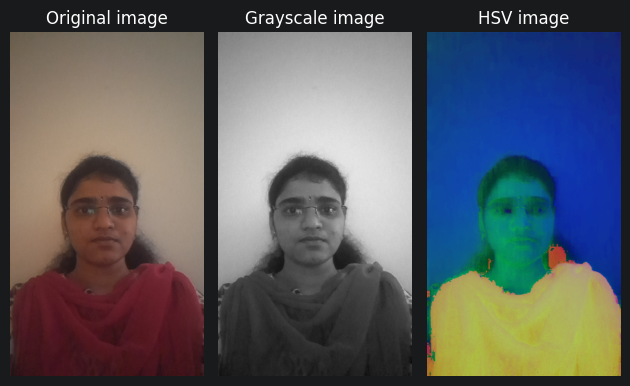

In [12]:
plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title('Original image')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_gray,cmap='gray')
plt.title('Grayscale image')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(img_hsv)
plt.title('HSV image')
plt.axis('off')

plt.tight_layout()
plt.show()


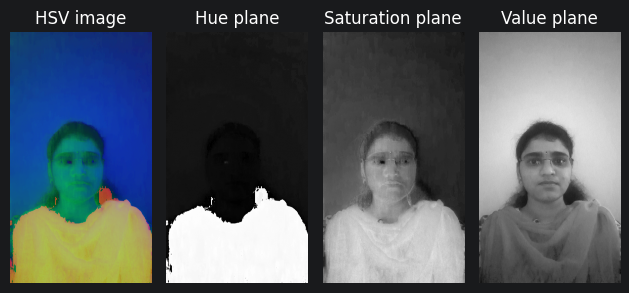

In [10]:
plt.subplot(1,4,1)
plt.imshow(img_hsv)
plt.title('HSV image')
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(img_hsv[:,:,0], cmap='gray')
plt.title('Hue plane')
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(img_hsv[:,:,1], cmap='gray')
plt.title('Saturation plane')
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(img_hsv[:,:,2], cmap='gray')
plt.title('Value plane')
plt.axis('off')

plt.tight_layout()
plt.show()

The value channel looks best in preserving the the details in the darkest part. In low light image the color information is weak and the purity of the color is difficult to differentiate. Hence change in brightness retains maximum information

Task 2: Image Blending via Feature matching

TODO:
1. Detect keypoints and descriptors
2. Match them
3. Estimate homograph
4. Wrap low light over normal light image

In [3]:
img_files

['Distinct_object_capture.jpg.jpeg',
 'Handwritten_capture.jpg.jpeg',
 'Low_light_capture.jpg.jpeg',
 'Normal_light_capture.jpg.jpeg',
 'Object_video_capture.mp4']

In [4]:
# Loading the images
img_path_low = os.path.join(folder, img_files[2])
img_path_norm = os.path.join(folder, img_files[3])
img_bgr_norm = cv2.imread (img_path_norm)
img_bgr_low = cv2.imread(img_path_low)


# Converting to grayscale
norm_img_gray = cv2.cvtColor(img_bgr_norm, cv2.COLOR_BGR2GRAY)
low_img_gray = cv2.cvtColor(img_bgr_low, cv2.COLOR_BGR2GRAY)

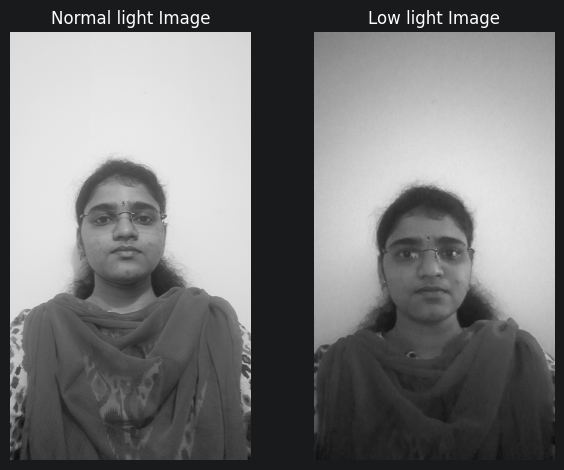

In [5]:
#Displaying the imported image

plt.subplot(1,2,1)
plt.imshow(norm_img_gray,cmap='gray')
plt.title('Normal light Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(low_img_gray,cmap='gray')
plt.title('Low light Image')
plt.axis('off')

plt.tight_layout()
plt.show()

In [6]:
# create ORB object
orb = cv2.ORB_create()

# Getting Keypoints and descriptors
kp1, des1 = orb.detectAndCompute(norm_img_gray,None)
kp2, des2 = orb.detectAndCompute(low_img_gray,None)

In [7]:
# Creating brute force matcher
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck = True)
# Matching the descriptors
matches = bf.match(des1,des2)
#sort the matches
matches = sorted(matches, key = lambda x:x.distance)

In [8]:
# Drawing first 50 matches
matched_img = cv2.drawMatches(
    img_bgr_norm, kp1, img_bgr_low, kp2,
    matches[:50], None,flags = cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)


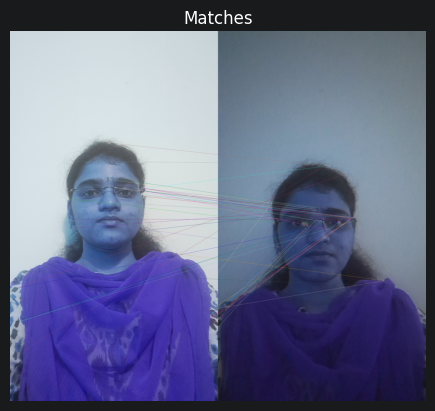

In [9]:
plt.imshow(matched_img)
plt.title("Matches")
plt.axis('off')
plt.show()

In [10]:
# Homographic Matrix
scr_pt = np.float32(
    [kp1[m.queryIdx].pt for m in matches]
    ).reshape(-1,1,2)
dst_pt = np.float32(
    [kp2[m.trainIdx].pt for m in matches]
    ).reshape(-1,1,2)

#finding homography
H, mask = cv2.findHomography(scr_pt,dst_pt,cv2.RANSAC,5.0)


In [11]:
height, width = img_bgr_norm.shape[:2]
warped = cv2.warpPerspective(img_bgr_low,H,(width,height))

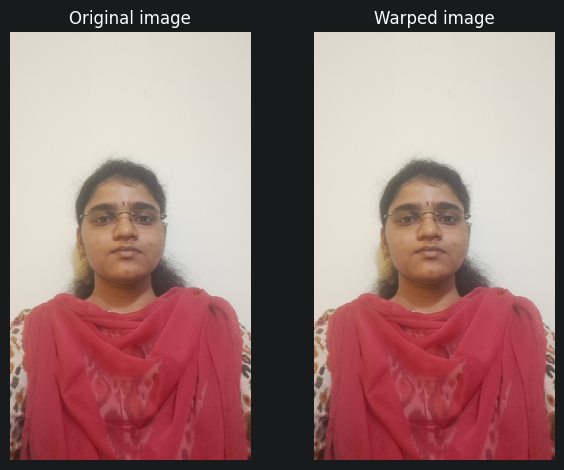

In [12]:
warped[:height,:width] = img_bgr_norm

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img_bgr_norm,cv2.COLOR_BGR2RGB))
plt.title('Original image')
plt.axis('off')


plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
plt.title('Warped image')
plt.axis('off')

plt.tight_layout()
plt.show()

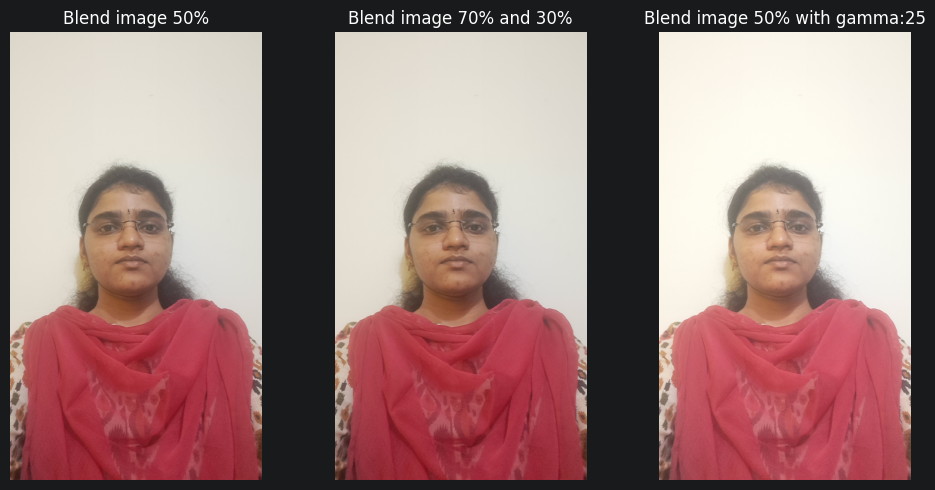

In [13]:
blend1 = cv2.addWeighted(img_bgr_norm,0.5,warped,0.5,0)
blend2 = cv2.addWeighted(img_bgr_norm,0.7,warped,0.3,0)
blend3 = cv2.addWeighted(img_bgr_norm,0.5,warped,0.5,25)
plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(blend1,cv2.COLOR_BGR2RGB))
plt.title('Blend image 50%')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(blend2,cv2.COLOR_BGR2RGB))
plt.title('Blend image 70% and 30%')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(blend3,cv2.COLOR_BGR2RGB))
plt.title('Blend image 50% with gamma:25')
plt.axis('off')

plt.tight_layout()
plt.show()

Had used top 50 good matches out of 72 matches. In the addWeighted() we use portion of the original image and a portion of the wrapped image, while wrapPerspective will blend the entire image over the other image.

Task 3: Geometric Transformation

Angle = 17 * 3 deg = 51 deg

Scale = 1 + ( 17 / 10 ) = 2.7

In [3]:
#Loading the object image
obj_path = os.path.join(folder, img_files[0])
obj_img = cv2.imread(obj_path)
obj_rgb = cv2.cvtColor(obj_img, cv2.COLOR_BGR2RGB)

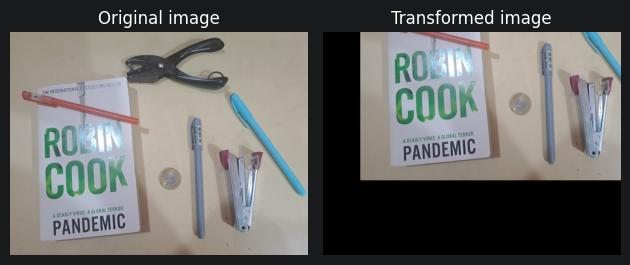

In [4]:
# Transition
tx = 500 #change in x direction
ty = -1000 #change in y direction
Mat = np.float32(
    [[1,0,tx],
     [0,1,ty]]
) # the identity matrix maintains the scale and angle the same

obj_trans = cv2.warpAffine(
    obj_rgb, Mat, (obj_rgb.shape[1], obj_rgb.shape[0])
)
plt.subplot(1,2,1)
plt.imshow(obj_rgb)
plt.title('Original image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(obj_trans)
plt.title('Transformed image')
plt.axis('off')

plt.tight_layout()
plt.show()

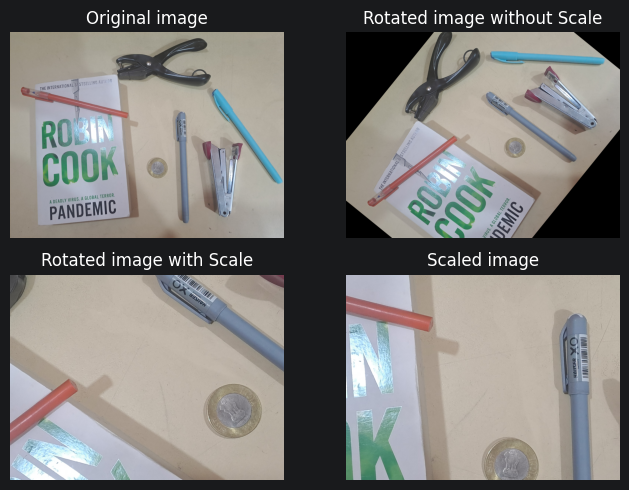

In [5]:
# Rotation and Scaling
height, width = obj_rgb.shape[:2]
center = (width//2, height//2)
rot_mat_1 = cv2.getRotationMatrix2D(center, 51, 1)
rot_mat_2 = cv2.getRotationMatrix2D(center, 51, 2.7)
# with rotation 0 deg, the image is only scaled
scale_mat = cv2.getRotationMatrix2D(center, 0, 2.7)
obj_rot1 = cv2.warpAffine(obj_rgb, rot_mat_1, (width,height))
obj_rot2 = cv2.warpAffine(obj_rgb, rot_mat_2, (width,height))
scaled_img = cv2.warpAffine(obj_rgb, scale_mat, (width,height))

plt.figure(figsize=(7,5))
plt.subplot(2,2,1)
plt.imshow(obj_rgb)
plt.title('Original image')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(obj_rot1)
plt.title('Rotated image without Scale')
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(obj_rot2)
plt.title('Rotated image with Scale')
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(scaled_img)
plt.title('Scaled image')
plt.axis('off')

plt.tight_layout()
plt.show()


Affine transform, changes image by mapping three points to other three points

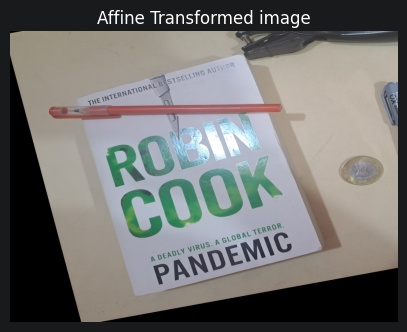

In [7]:
pt_1 = np.float32(
    [[50,50],
    [200,50],
    [50,200]])
pt_2 = np.float32(
    [[30,70],
    [250,30],
    [70,220]])

# to create the matrix we use getAffineTransform
aff_mat = cv2.getAffineTransform(pt_1, pt_2)

affine_img = cv2.warpAffine(obj_rgb, aff_mat, (width,height))
plt.figure(figsize=(5,5))
plt.imshow(affine_img)
plt.title('Affine Transformed image')
plt.axis('off')
plt.show()

Task 4: Noise and Filter

TODO:

1. Add Gaussian noise to text image (mean = 0, sigma = 25)
2. Prediction : Median filter, as it preserves edges and replaces the median value
3. Apply all 4 filters on the noisy image.

In [31]:
txt_path = os.path.join(folder, img_files[1])
txt_img = cv2.imread(txt_path)
txt_rgb = cv2.cvtColor(txt_img, cv2.COLOR_BGR2RGB)
# Adding noise
mean = 0
sigma = 25
noise = np.random.normal(mean, sigma, txt_img.shape)
noise = np.clip(noise, 0, 255).astype(np.uint8)
noisy_img = txt_rgb + noise


In [32]:
# Mean filter
mean_filt = cv2.blur(noisy_img, (5,5))
# Median filter
med_filt = cv2.medianBlur(noisy_img, 5)
# Gaussian filter
gauss_filt = cv2.GaussianBlur(noisy_img, (5,5), 0)
# Bilateral filter
bilat_filt = cv2.bilateralFilter(noisy_img, 5, 75, 75)

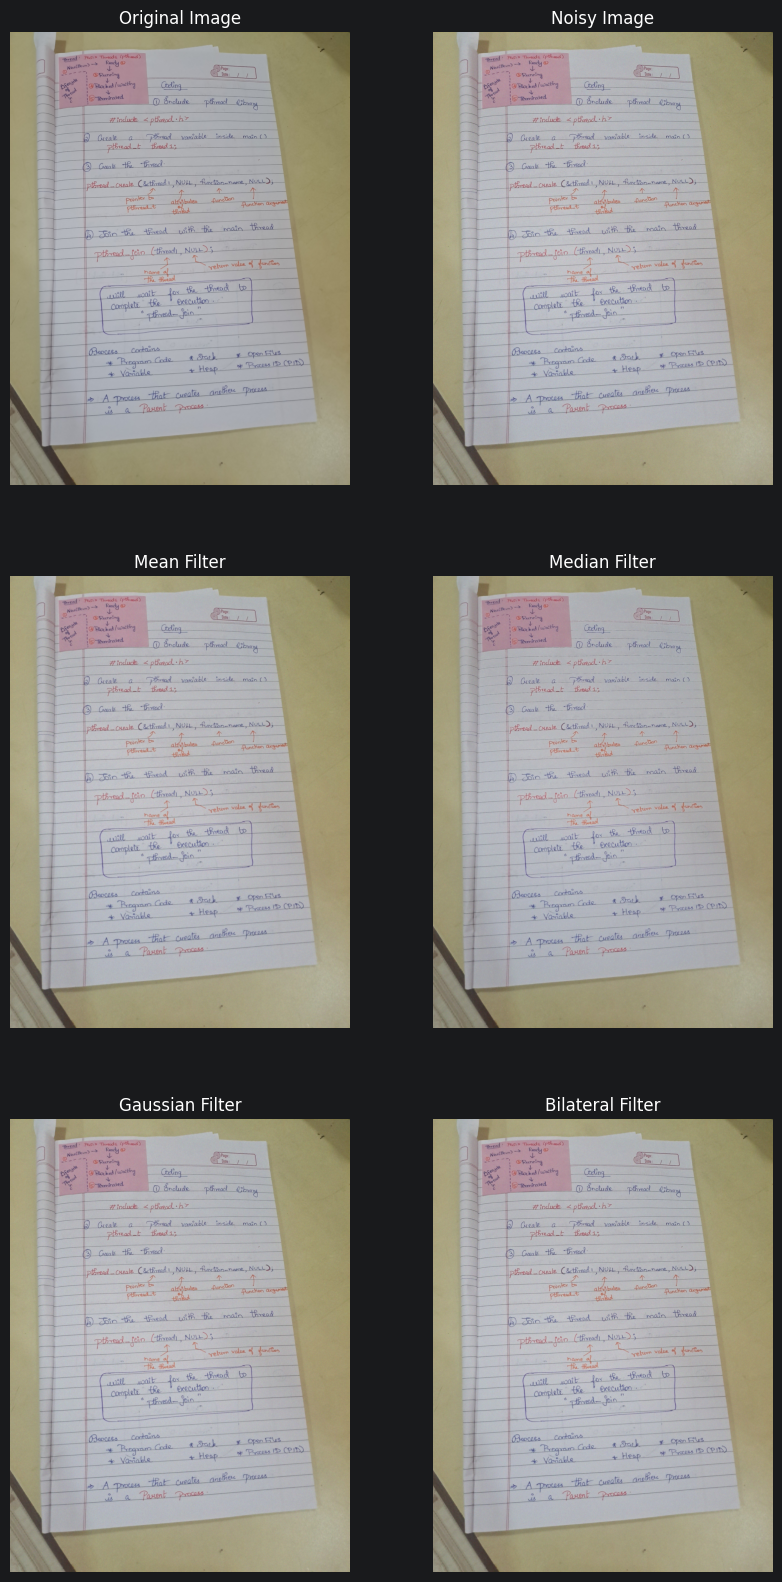

In [33]:
img_titles = ['Original Image', 'Noisy Image', 'Mean Filter',
              'Median Filter', 'Gaussian Filter', 'Bilateral Filter']
filt_imgs = [txt_rgb, noisy_img, mean_filt,
             med_filt, gauss_filt, bilat_filt]

plt.figure(figsize=(10,20))
for i in range(len(filt_imgs)):
    plt.subplot(3,2,i+1)
    plt.imshow(filt_imgs[i])
    plt.title(img_titles[i])
    plt.axis('off')

plt.show()

Medium noise is added and the Median filter and Bilateral filter extract the edges well compared to the others.

Task 5: Edge and Contour Detection

TODO:

1. Canny edge detection
2. Auto count using cv2.findContours, submit annotated img

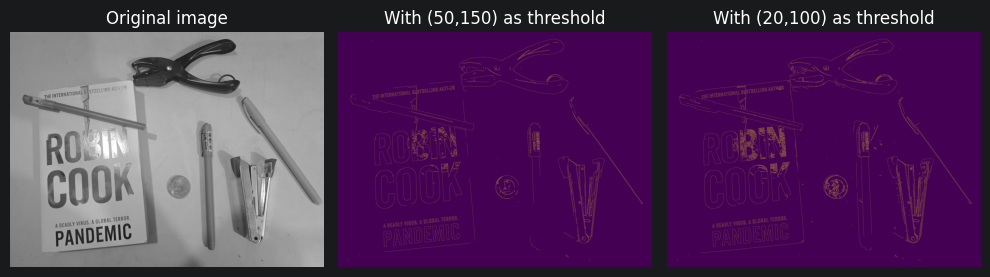

In [22]:
obj_path = os.path.join(folder, img_files[0])
obj_img = cv2.imread(obj_path)
obj_gray = cv2.cvtColor(obj_img, cv2.COLOR_BGR2GRAY)
# Gaussian blur to smoothen the image
blur = cv2.GaussianBlur(obj_gray, (5,5), 0)
# Canny edge detection
edges_1 = cv2.Canny(blur, 50, 150) # With given threshold
edges_2 = cv2.Canny(blur, 20, 100)

plt.figure(figsize=(10,10))

plt.subplot(1,3,1)
plt.imshow(obj_gray,cmap='gray')
plt.title('Original image')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(edges_1)
plt.title('With (50,150) as threshold')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(edges_2)
plt.title('With (20,100) as threshold')
plt.axis('off')

plt.tight_layout()
plt.show()

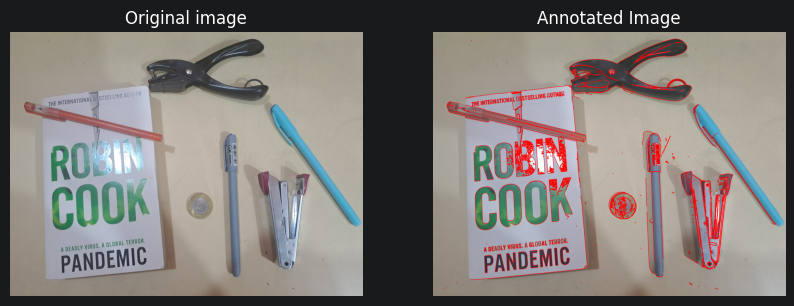

In [35]:
# Draw contours
contours,_ = cv2.findContours(edges_2, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

output_img = obj_img.copy()
cv2.drawContours(output_img, contours, -1, (0,0,255), 3)
plt.figure(figsize=(10,10))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(obj_img, cv2.COLOR_BGR2RGB))
plt.title('Original image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
plt.title('Annotated Image')
plt.axis('off')
plt.show()